In [1]:
import numpy as np #linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df=pd.read_csv('Social_Network_Ads.csv') 

In [4]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
df=df.iloc[:,2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
328,36,118000,1
93,29,28000,0
394,39,59000,0
59,32,117000,0
30,31,74000,0


# Train test split

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test= train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [10]:
X_train.shape,X_test.shape

((280, 2), (120, 2))

# StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

#fit the scaler to train ser ,it will learn the parameters

scaler.fit(X_train)

#transform train and test sets
X_test_scaled= scaler.transform(X_train)
X_train_scaled=scaler.transform(X_train)

In [12]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [13]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [15]:
#converting the train scaled dataset numpy array to table

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [16]:
X_test_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [17]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [18]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of scaling


Text(0.5, 1.0, 'After scalling')

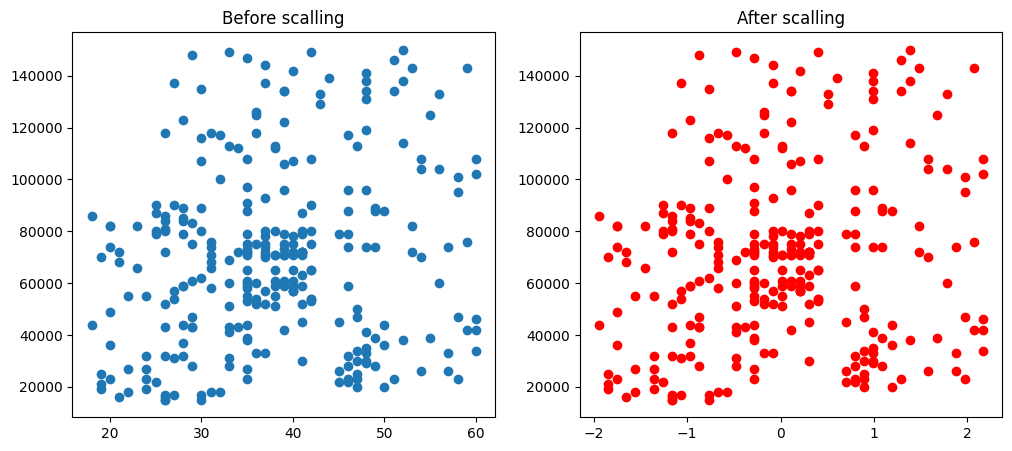

In [23]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before scalling")

ax2.scatter(X_train_scaled['Age'],X_train['EstimatedSalary'],color='Red')
ax2.set_title("After scalling")


<Axes: title={'center': 'After scaling'}, xlabel='Age', ylabel='Density'>

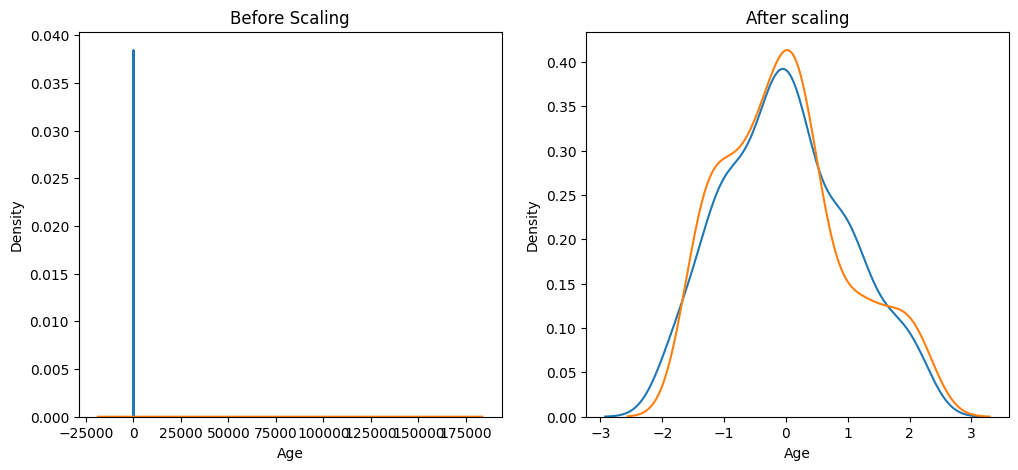

In [26]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scalling

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title("After scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)